In [12]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [14]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [15]:
# Fix horsepower column
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop non-numeric column
df.drop("car name", axis=1, inplace=True)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [16]:
X = df.drop("mpg", axis=1)   # use all 7 features # inputs
y = df['mpg']  # output

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    398 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Second split: Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)



In [20]:
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))
print("Test size:", len(X_temp))

Train size: 278
Validation size: 60
Test size: 60
Test size: 120


In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [25]:
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression:
MAE: 2.3743289531114127
RMSE: 3.099030627063097
R2: 0.8538203870200514


In [26]:
print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest:
MAE: 1.7434166666666655
RMSE: 2.6352338194804137
R2: 0.8943003907157694


In [27]:
import joblib

joblib.dump(rf, "model.pkl")   # save best model
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

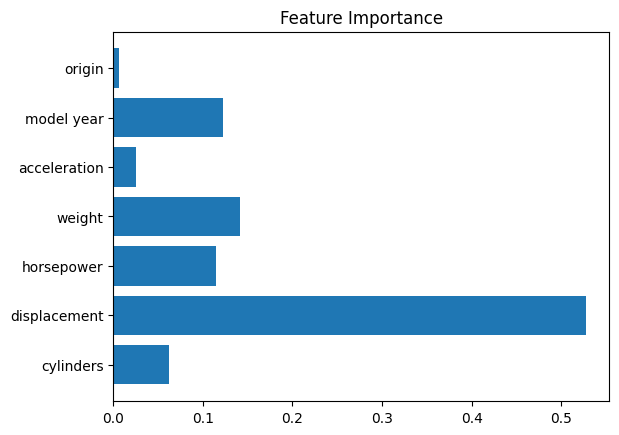

In [28]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 200}


In [30]:
# ==============================
# 7. TRAIN MODELS
# ==============================

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ==============================
# 8. VALIDATION PERFORMANCE
# ==============================

def evaluate(model, X, y, name):
    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    print(f"\n{name} Performance:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score (Accuracy-like):", r2)

# Evaluate on validation set
evaluate(lr, X_val, y_val, "Linear Regression")
evaluate(rf, X_val, y_val, "Random Forest")

# ==============================
# 9. FINAL TEST EVALUATION
# ==============================

# Choose best model (usually Random Forest)
best_model = rf

evaluate(best_model, X_test, y_test, "Final Model (Test Set)")

# ==============================
# 10. SAVE MODEL
# ==============================

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model and scaler saved!")


Linear Regression Performance:
MAE: 2.363093748597709
RMSE: 2.99223254684372
R2 Score (Accuracy-like): 0.8175221611314883

Random Forest Performance:
MAE: 1.8401166666666664
RMSE: 2.4178866357489412
R2 Score (Accuracy-like): 0.8808507498631661

Final Model (Test Set) Performance:
MAE: 1.7434166666666655
RMSE: 2.6352338194804137
R2 Score (Accuracy-like): 0.8943003907157694

✅ Model and scaler saved!


In [34]:
# Test prediction with example data
# Replace these values with your own
cylinders = 6
displacement = 250
horsepower = 150
weight = 3500
acceleration = 10
model_year = 75
origin = 1

# Convert to array
data = np.array([[cylinders, displacement, horsepower, weight, acceleration, model_year, origin]])

# Scale
data_scaled = scaler.transform(data)

# Predict
prediction = best_model.predict(data_scaled)

print("\n🚗 Predicted MPG:", prediction[0])


🚗 Predicted MPG: 16.013


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
